# **1. Preprocessing**

In [15]:
import pandas as pd
import numpy as np


In [16]:
from google.colab import files
uploaded = files.upload()

Saving Book 1 3.xlsx to Book 1 3 (1).xlsx


In [17]:

df = pd.read_excel("Book 1 3.xlsx")
df.head()

,Age,Annual Income,Home ownership,Employment length,Loan intent,Loan grade,Loan amount,Interest rate,Percent income,Historical default,Credit history length,Loan status
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,59,Y,3,1
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,1,N,2,0
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,57,N,3,1
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,53,N,2,1
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,55,Y,4,1


There are observations which contain special character "?", we would replace these values with NA values

In [18]:

df = df.replace("?", np.nan)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    32581 non-null  int64 
 1   Annual Income          32581 non-null  int64 
 2   Home ownership         32581 non-null  object
 3   Employment length      31686 non-null  object
 4   Loan intent            32581 non-null  object
 5   Loan grade             32581 non-null  object
 6   Loan amount            32581 non-null  int64 
 7   Interest rate          29465 non-null  object
 8   Percent income         32581 non-null  int64 
 9   Historical default     32581 non-null  object
 10  Credit history length  32581 non-null  int64 
 11  Loan status            32581 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 3.0+ MB


While the dataset has 32581 observations, there are two wrong data types in the dataset: **Employment length** and **Interest rate**. Therefore, we change their data types. These two columns also have NaN values which we would handle later.

In [19]:
df[["Employment length", "Interest rate"]]=df[["Employment length", "Interest rate"]].astype(float)

In [20]:
df.dtypes

,0
Age,int64
Annual Income,int64
Home ownership,object
Employment length,float64
Loan intent,object
Loan grade,object
Loan amount,int64
Interest rate,float64
Percent income,int64
Historical default,object


In [21]:
df[['Employment length','Interest rate']].isna().sum()

,0
Employment length,895
Interest rate,3116


array([[<Axes: title={'center': 'Employment length'}>,
        <Axes: title={'center': 'Interest rate'}>]], dtype=object)

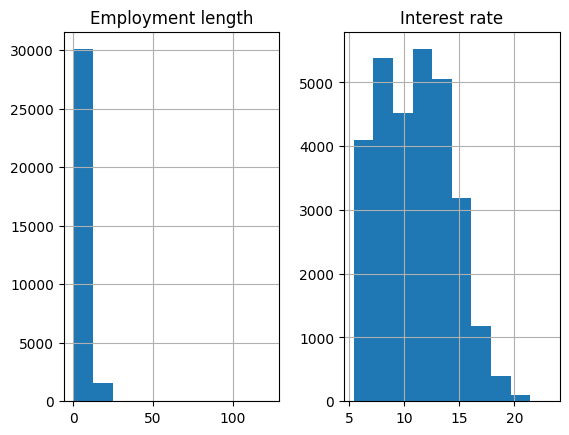

In [22]:
df[['Employment length','Interest rate']].hist()

Since the two variables are heavily right-skewed, we would replace the missing values with the median values

In [23]:
df['Employment length'] = df['Employment length'].fillna(
    df['Employment length'].median()
)

df['Interest rate'] = df['Interest rate'].fillna(
    df['Interest rate'].median()
)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    32581 non-null  int64  
 1   Annual Income          32581 non-null  int64  
 2   Home ownership         32581 non-null  object 
 3   Employment length      32581 non-null  float64
 4   Loan intent            32581 non-null  object 
 5   Loan grade             32581 non-null  object 
 6   Loan amount            32581 non-null  int64  
 7   Interest rate          32581 non-null  float64
 8   Percent income         32581 non-null  int64  
 9   Historical default     32581 non-null  object 
 10  Credit history length  32581 non-null  int64  
 11  Loan status            32581 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 3.0+ MB


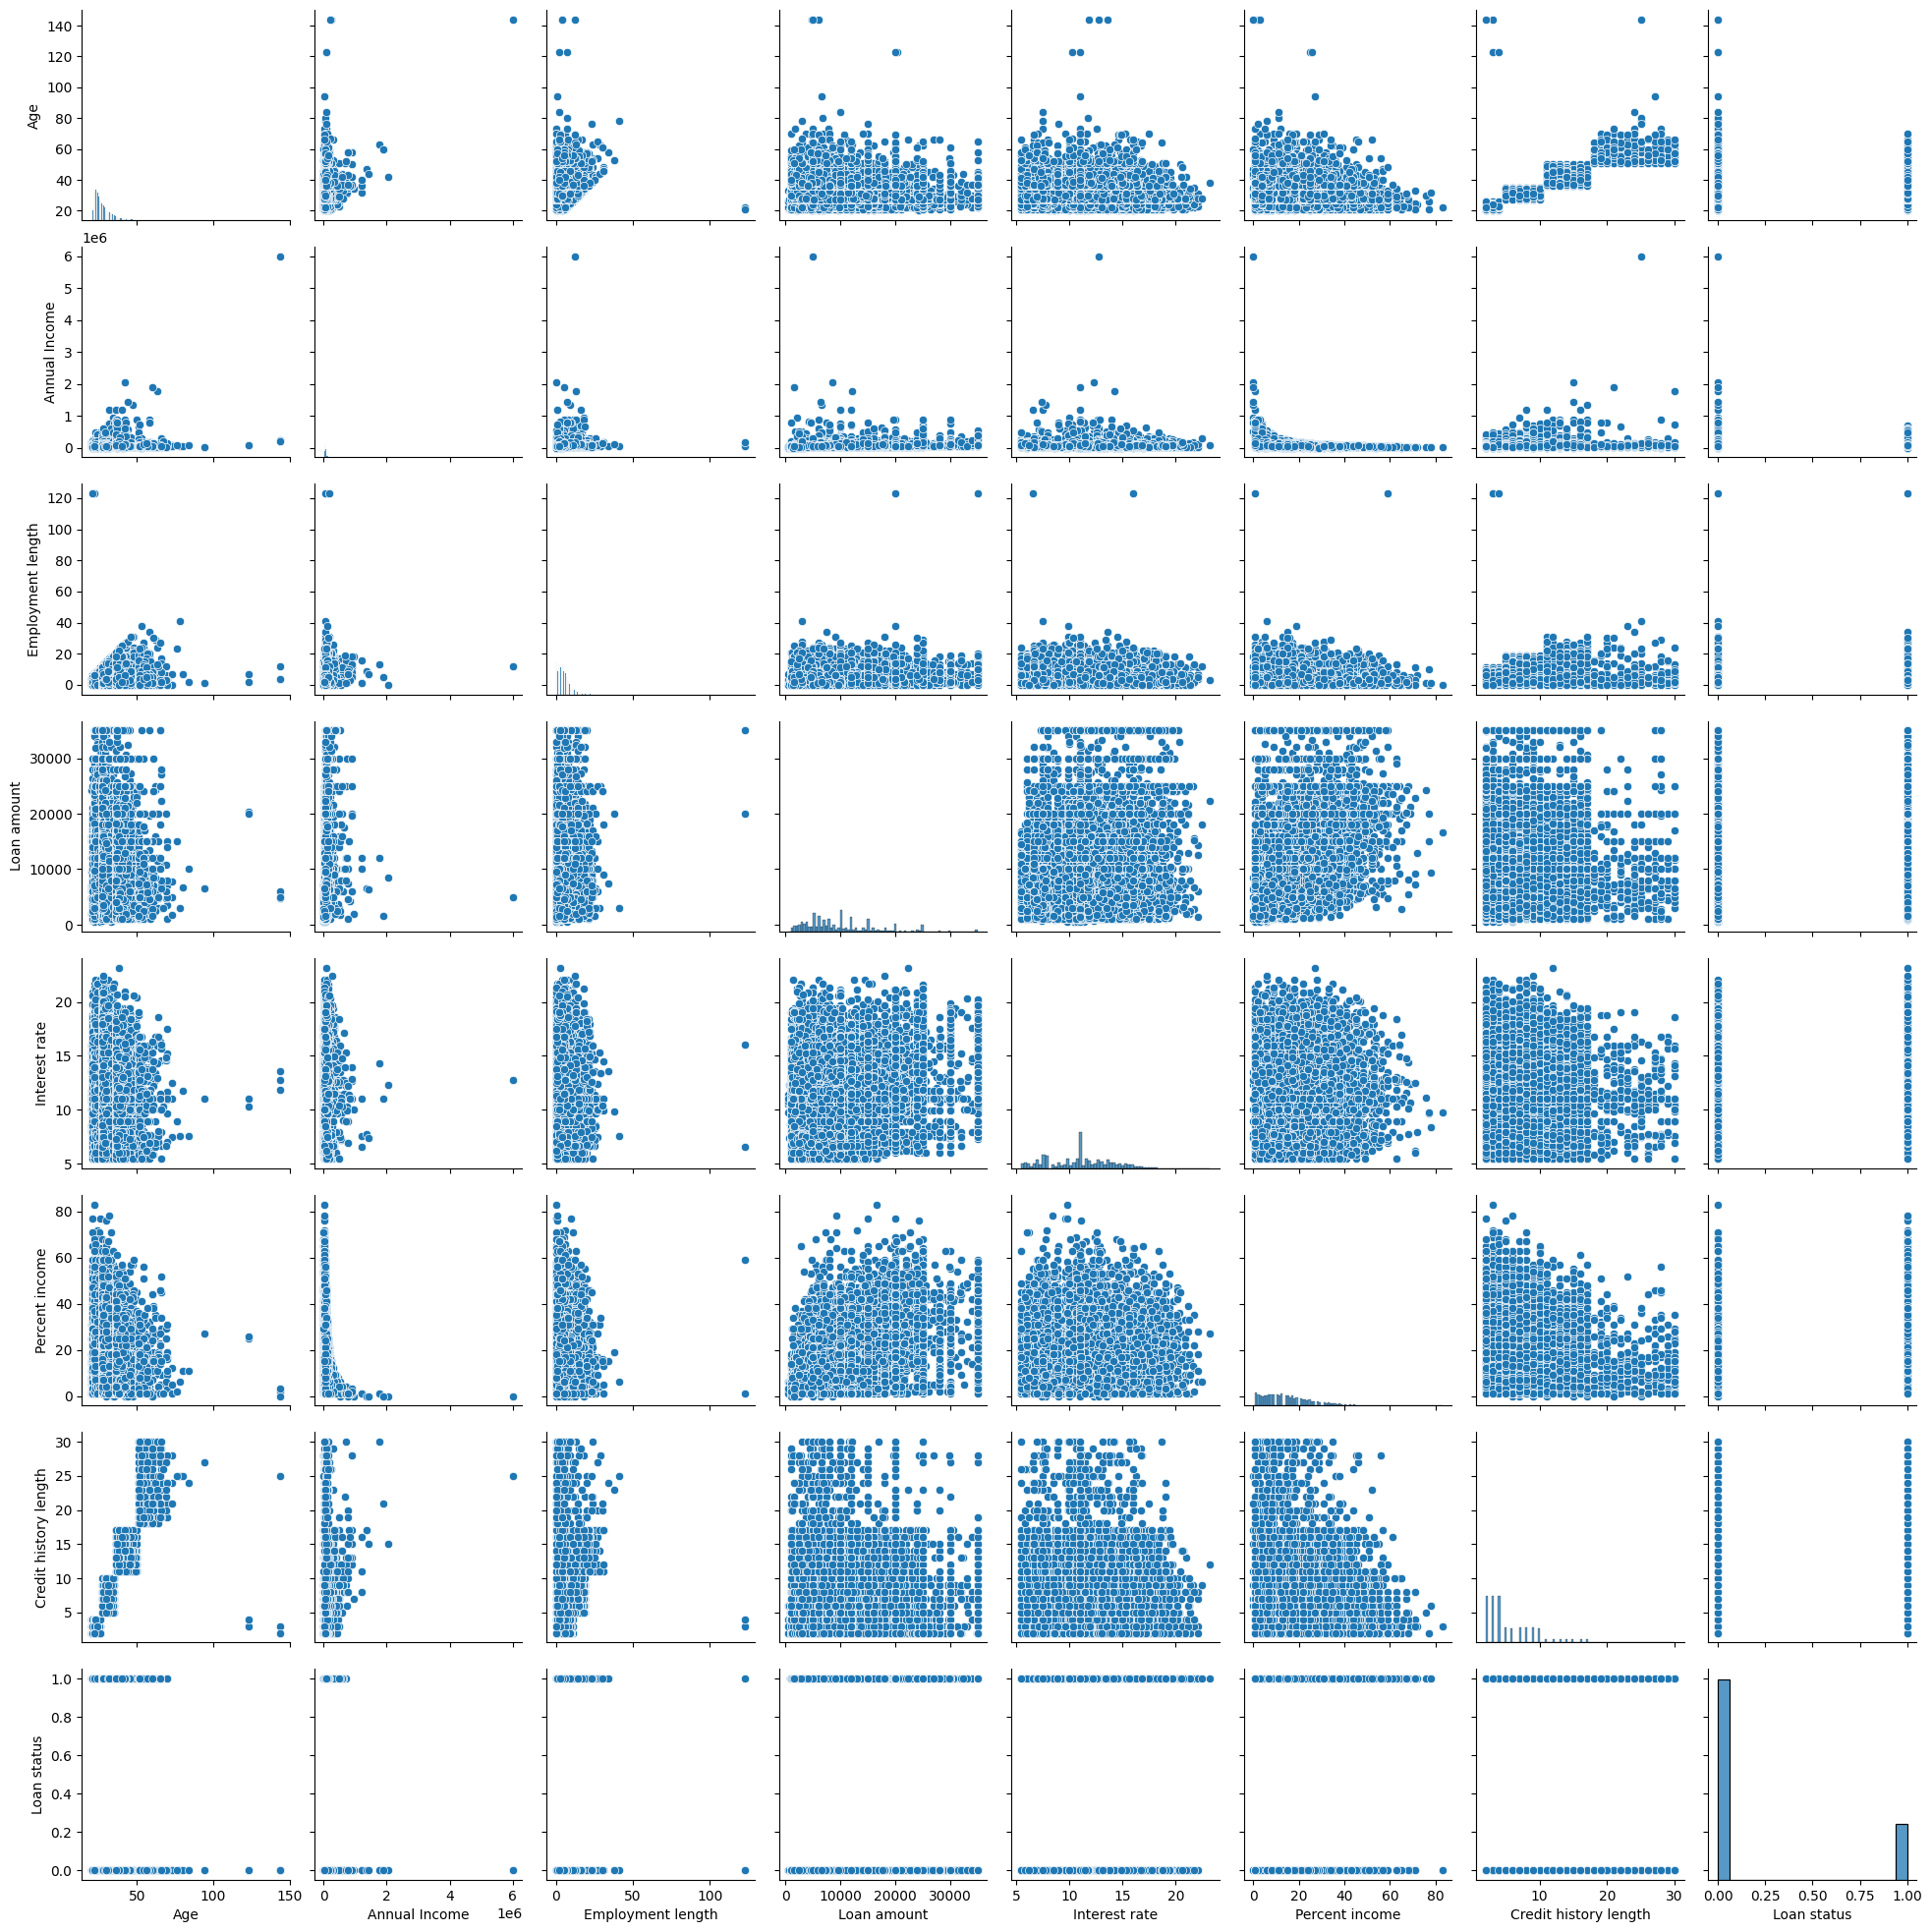

In [14]:
import seaborn as sns
sns.pairplot(data=df)

We would also explore the first column **Age** to ensure accuracy and consistency, excluding abnormal values.

In [25]:
df["Age"].value_counts()

,count
Age,
23,3889
22,3633
24,3549
25,3037
26,2477
27,2138
28,1854
29,1687
30,1316


Text(0, 0.5, 'Age')

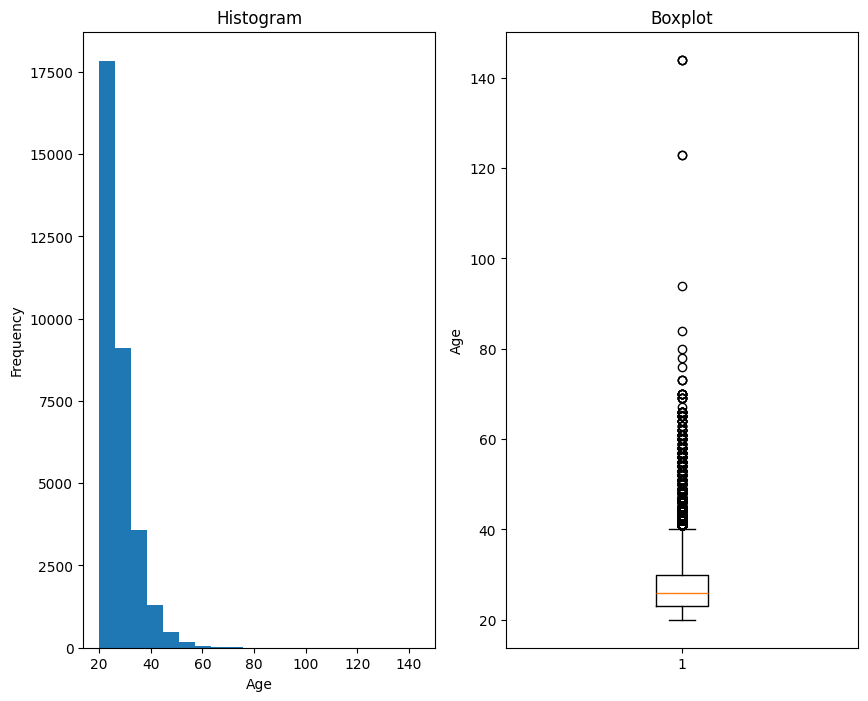

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 8))

ax[0].hist(df['Age'], bins=20)
ax[0].set_title('Histogram')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Frequency')

ax[1].boxplot(df['Age'])
ax[1].set_title("Boxplot")
ax[1].set_ylabel("Age")


There are several abnormal values in the Age feature such as 144, 123, 94. Therefore, the Age limit extends to over 140

In [28]:
abnormal=df[df["Age"]>80]
abnormal

,Age,Annual Income,Home ownership,Employment length,Loan intent,Loan grade,Loan amount,Interest rate,Percent income,Historical default,Credit history length,Loan status
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,2,N,3,0
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,3,N,2,0
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,25,N,3,0
747,123,78000,RENT,7.0,VENTURE,B,20000,10.99,26,N,4,0
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,N,25,0
32416,94,24000,RENT,1.0,MEDICAL,C,6500,10.99,27,N,27,0
32506,84,94800,MORTGAGE,2.0,PERSONAL,A,10000,7.51,11,N,24,0


In [29]:
len(abnormal)/len(df)

0.00021484914520732943

Since these values only constitute a negligible proportion of the dataset, these abnormal rows would be deleted. We would limit the Age value to 80

In [30]:
df=df[df['Age']<=80]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32574 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    32574 non-null  int64  
 1   Annual Income          32574 non-null  int64  
 2   Home ownership         32574 non-null  object 
 3   Employment length      32574 non-null  float64
 4   Loan intent            32574 non-null  object 
 5   Loan grade             32574 non-null  object 
 6   Loan amount            32574 non-null  int64  
 7   Interest rate          32574 non-null  float64
 8   Percent income         32574 non-null  int64  
 9   Historical default     32574 non-null  object 
 10  Credit history length  32574 non-null  int64  
 11  Loan status            32574 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 3.2+ MB


#**2. Exploring Continous Features**

We wil analyze continuous features in this section

Age
23    3889
22    3633
24    3549
25    3037
26    2477
27    2138
28    1854
29    1687
30    1316
21    1229
31    1142
32     964
33     856
34     709
35     620
36     548
37     478
38     373
39     302
40     271
41     241
42     188
43     164
44     141
45     108
46      94
47      94
48      75
50      52
49      49
51      39
52      36
53      30
54      24
55      20
58      19
20      15
57      15
56      15
60      15
65       9
66       9
61       9
64       7
70       7
62       7
59       5
69       5
73       3
63       3
78       1
80       1
76       1
67       1
Name: count, dtype: int64


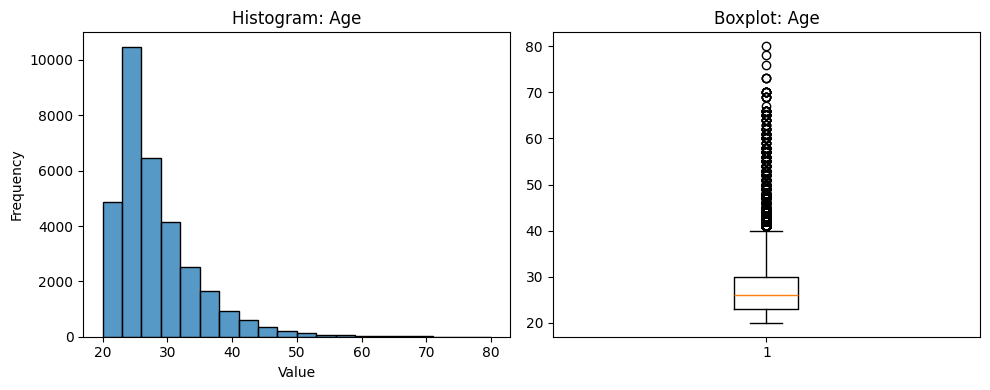

Annual Income
60000      1046
30000       847
50000       778
40000       658
45000       590
           ... 
720000        1
1900000       1
90750         1
24543         1
92111         1
Name: count, Length: 4294, dtype: int64


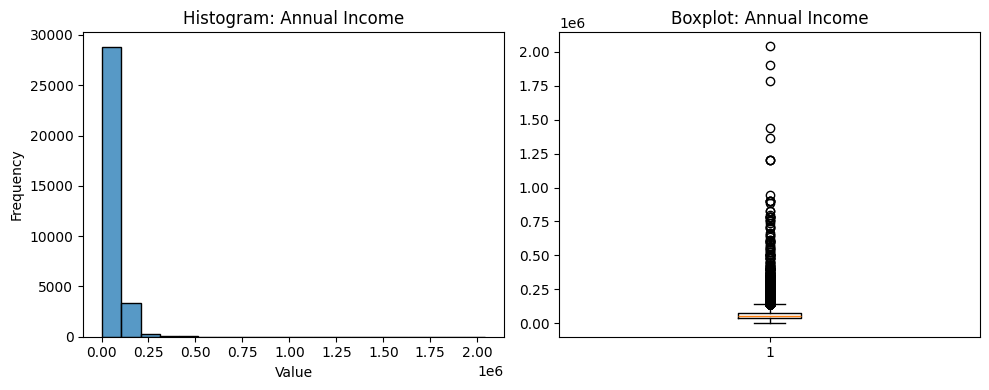

Employment length
0.0      4105
2.0      3847
4.0      3767
3.0      3456
5.0      2946
1.0      2914
6.0      2666
7.0      2195
8.0      1687
9.0      1367
11.0      740
10.0      696
12.0      574
13.0      426
14.0      335
15.0      238
16.0      165
17.0      129
18.0      104
19.0       64
20.0       42
21.0       38
22.0       19
24.0       10
23.0       10
25.0        8
26.0        6
27.0        5
31.0        4
28.0        3
123.0       2
30.0        2
41.0        1
34.0        1
29.0        1
38.0        1
Name: count, dtype: int64


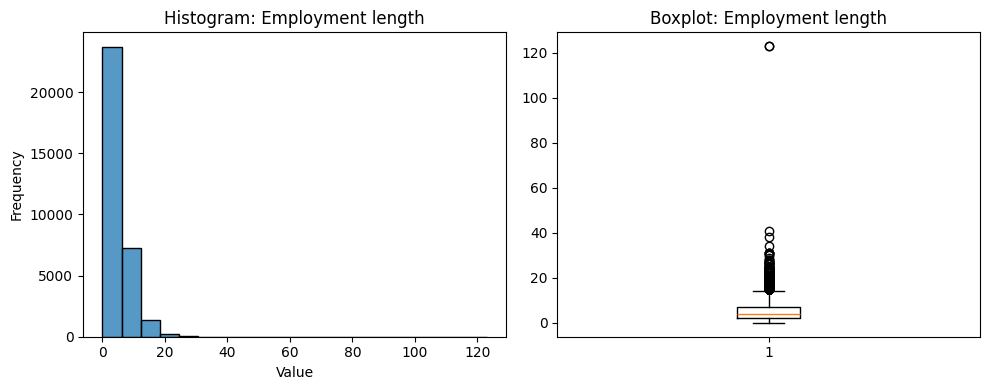

Loan amount
10000    2663
5000     2042
12000    1809
6000     1800
15000    1502
         ... 
23100       1
23700       1
3225        1
23325       1
8175        1
Name: count, Length: 753, dtype: int64


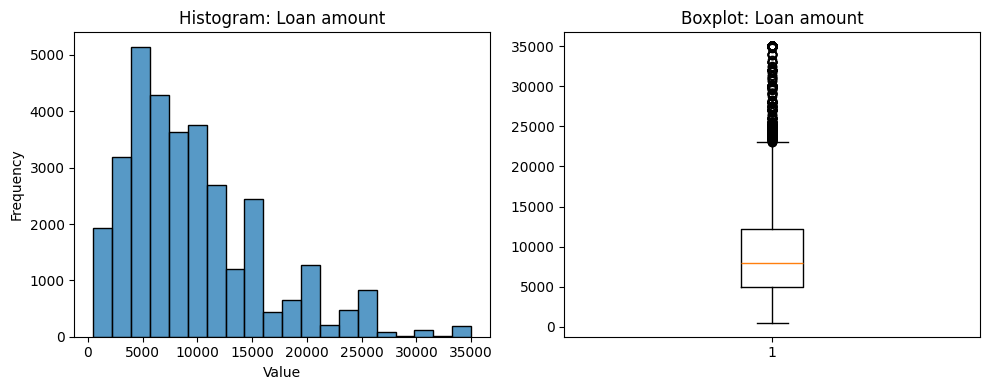

Interest rate
10.99    3863
7.51      755
7.49      645
7.88      642
5.42      594
         ... 
23.22       1
16.71       1
18.54       1
20.69       1
20.53       1
Name: count, Length: 348, dtype: int64


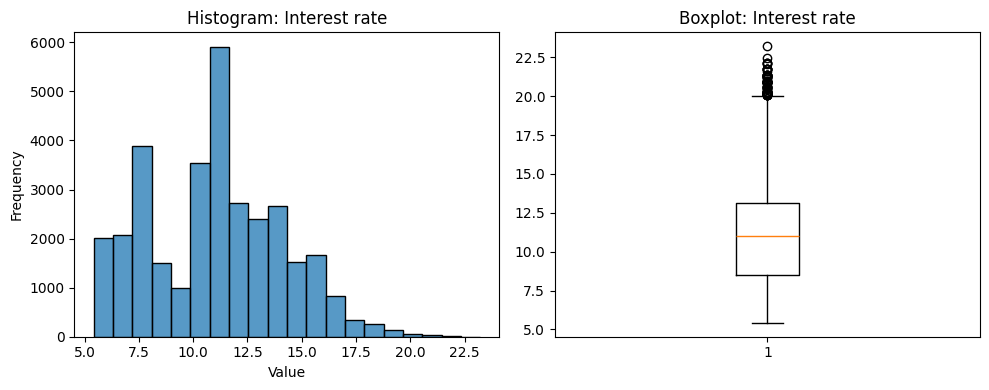

Percent income
1     1672
13    1482
2     1440
8     1437
7     1397
      ... 
72       1
83       1
76       1
62       1
78       1
Name: count, Length: 70, dtype: int64


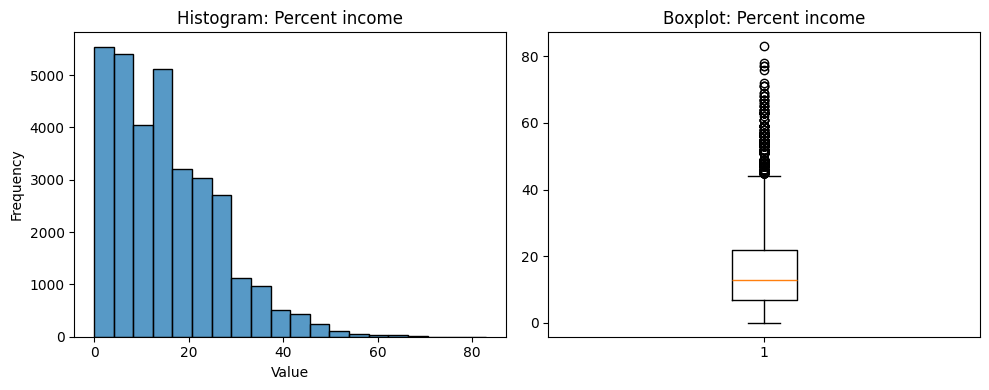

Credit history length
2     5964
3     5941
4     5924
8     1902
7     1901
9     1895
5     1881
6     1857
10    1850
14     492
12     485
11     463
16     451
13     443
15     437
17     407
20      31
24      29
28      27
22      22
30      22
23      22
27      21
19      21
21      20
18      19
25      17
26      16
29      14
Name: count, dtype: int64


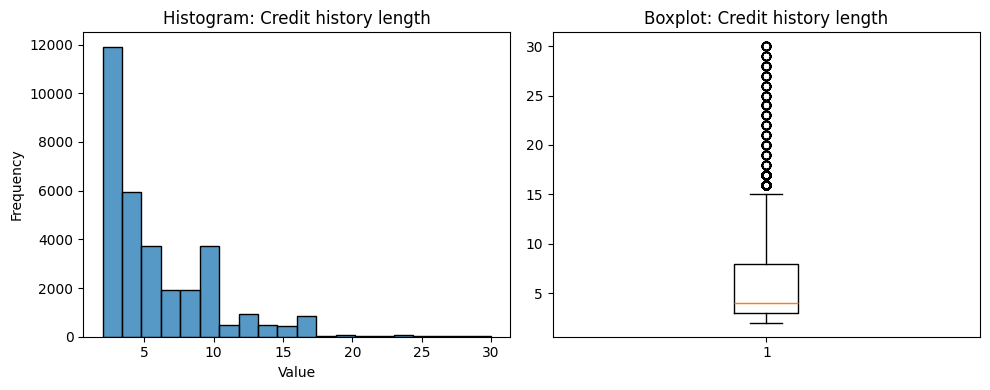

In [31]:
continuous_cols = df.select_dtypes(include='number').columns
continuous_cols = [col for col in continuous_cols if col != "Loan status"]

for col in continuous_cols:

    print(df[col].value_counts())
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))


    sns.histplot(data=df[col],bins=20, ax=ax[0])
    ax[0].set_title(f'Histogram: {col}')
    ax[0].set_xlabel("Value")
    ax[0].set_ylabel("Frequency")

    ax[1].boxplot(df[col])
    ax[1].set_title(f'Boxplot: {col}')

    plt.tight_layout()
    plt.show()

* The distribution of **Age** is concentrated toward the lower end, indicating that most borrowers belong to a relatively young demographic.
* Regarding **Annual Income**, the majority of borrowers fall into the lower-income group, while only a small proportion earn relatively high incomes.
* The **Employment Length** distribution shows that most borrowers have relatively short employment histories, with the majority having fewer than 20 months of employment. One notable exception is a borrower with 123 months of employment.
* Although most borrowers request relatively small **Loan Amounts**, a considerable number of borrowers apply for substantially larger loans, resulting in a right-skewed distribution.
* The distribution of **Interest Rate** contains fewer extreme values than the other numerical variables, indicating a relatively less skewed distribution.
* The **Percent Income** distribution suggests that most borrowers request loans representing only a small proportion of their annual income, while relatively few borrowers have high loan-to-income ratios.
* Finally, the **Credit History Length** distribution indicates that most borrowers have relatively short credit histories, suggesting that many applicants have limited credit experience.

Most of historgram show these variables are heavily right-skewed, meaning the tail of the plot is longer on the right end. The boxplots also show there are many points extend beyond the upper limit. Next, we would try to find these observations in the dataset.

**Note**: The purpose of identifying these observations is to better understand the characteristics of the dataset. These observations will not be removed, as they may represent valid customer records rather than data entry errors.

**Z-score**

In [32]:
from scipy.stats import zscore

for col in continuous_cols:

    z = zscore(df[col])

    outliers = df[np.abs(z) > 3]

    print(f"{col}")
    print(f"Number of outliers: {len(outliers)}")
    print("-"*40)

Age
Number of outliers: 551
----------------------------------------
Annual Income
Number of outliers: 355
----------------------------------------
Employment length
Number of outliers: 321
----------------------------------------
Loan amount
Number of outliers: 337
----------------------------------------
Interest rate
Number of outliers: 51
----------------------------------------
Percent income
Number of outliers: 273
----------------------------------------
Credit history length
Number of outliers: 281
----------------------------------------


**Hampel filter**

In [33]:

def hampel_filter(series, n_sigma=3):

    median = np.median(series)

    mad = np.median(np.abs(series - median))

    threshold = 1.4826 * mad * n_sigma

    outlier_idx = np.abs(series - median) > threshold

    return outlier_idx
for col in continuous_cols:

    outliers = df[hampel_filter(df[col])]

    print(col)
    print("Outliers:", len(outliers))
    print("-"*40)

Age
Outliers: 1758
----------------------------------------
Annual Income
Outliers: 1462
----------------------------------------
Employment length
Outliers: 1614
----------------------------------------
Loan amount
Outliers: 1259
----------------------------------------
Interest rate
Outliers: 12
----------------------------------------
Percent income
Outliers: 550
----------------------------------------
Credit history length
Outliers: 2511
----------------------------------------


In [34]:
for col in continuous_cols:
  skew = df[col].skew()
  if skew > 1:
        print(f"{col}: {skew:.2f}")

Age: 1.90
Annual Income: 9.75
Employment length: 2.66
Loan amount: 1.19
Percent income: 1.00
Credit history length: 1.66


Again, the skewness values of these variables are greater than 1, indicating that they are heavily right-skewed. Therefore, a log transformation will be applied to these features to reduce skewness and make their distributions more symmetric. However, **Age**, **Employment length** and **Credit History Length** will be excluded from this transformation because they represent naturally bounded demographic characteristics and their distributions remain meaningful in their original scale.

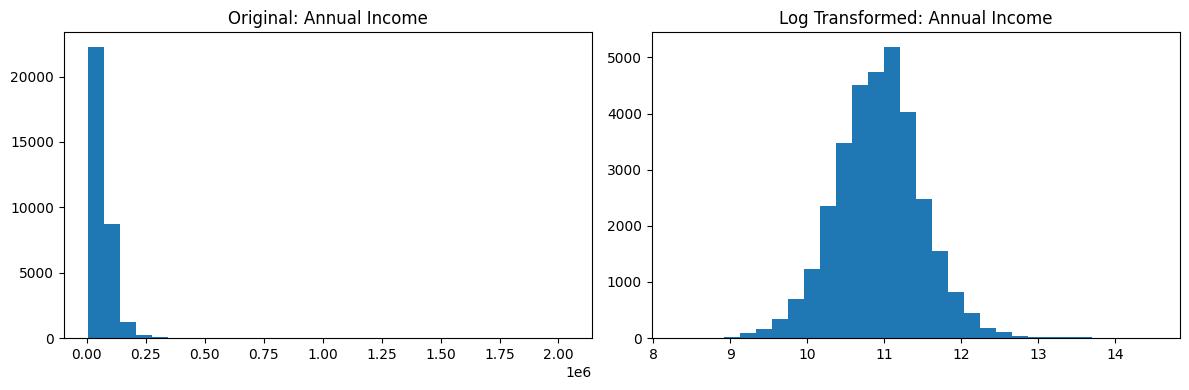

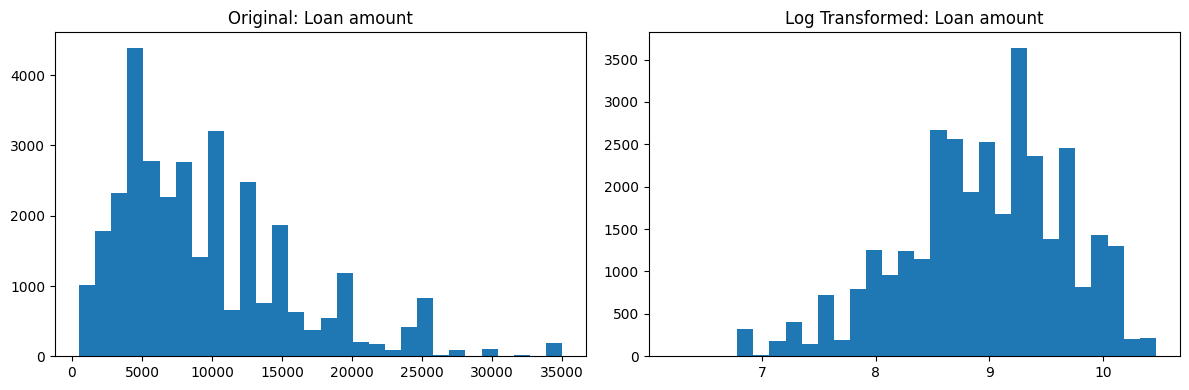

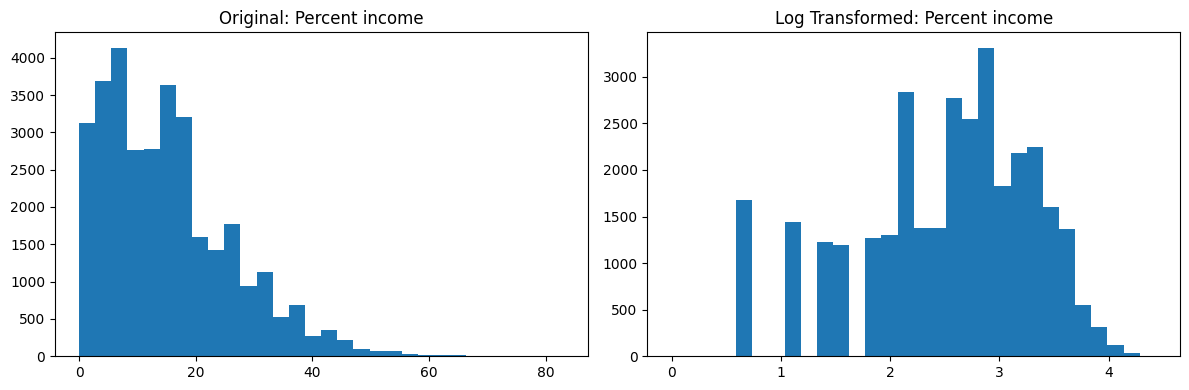

In [35]:
import numpy as np
import matplotlib.pyplot as plt
continuous_cols=["Annual Income","Loan amount","Percent income"]
for col in continuous_cols:
    plt.figure(figsize=(12,4))


    plt.subplot(1,2,1)
    plt.hist(df[col], bins=30)
    plt.title(f'Original: {col}')


    plt.subplot(1,2,2)
    plt.hist(np.log1p(df[col]), bins=30)
    plt.title(f'Log Transformed: {col}')

    plt.tight_layout()
    plt.show()

* After the log transformation, the distributions are less skewed and more closely resemble a normal distribution.
* **Note:** The log transformation is performed to reduce the skewness of selected numerical variables and improve their interpretability during exploratory data analysis. However, because this is a classification problem, the transformation is not essential, and its usefulness will be assessed empirically by comparing model performance before and after transformation

# **3. Categorical variables**

In [36]:
categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)

Index(['Home ownership', 'Loan intent', 'Loan grade', 'Historical default'], dtype='object')


Home ownership
RENT        16442
MORTGAGE    13441
OWN          2584
OTHER         107
Name: count, dtype: int64
Loan intent
EDUCATION            6451
MEDICAL              6070
VENTURE              5717
PERSONAL             5519
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64
Loan grade
A    10776
B    10448
C     6455
D     3626
E      964
F      241
G       64
Name: count, dtype: int64
Historical default
N    26829
Y     5745
Name: count, dtype: int64


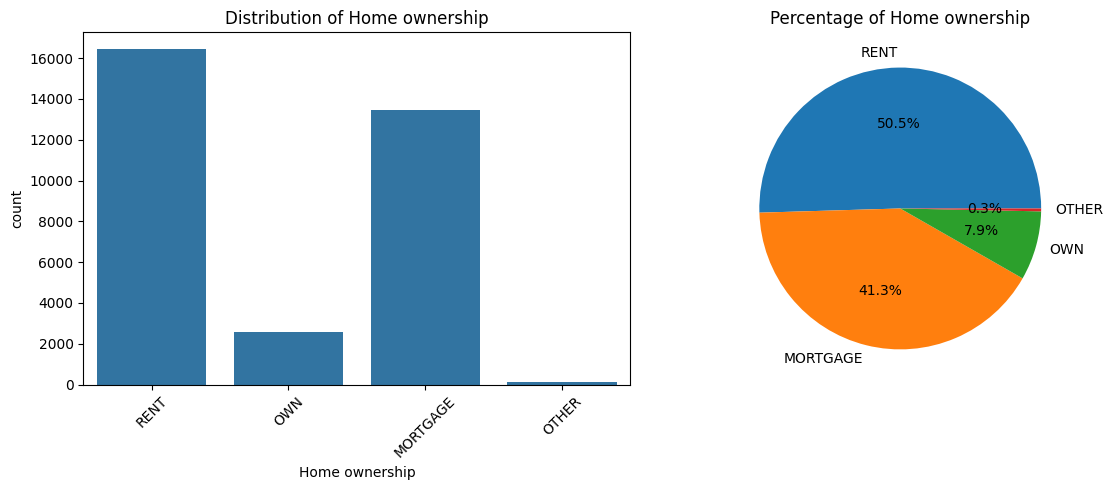

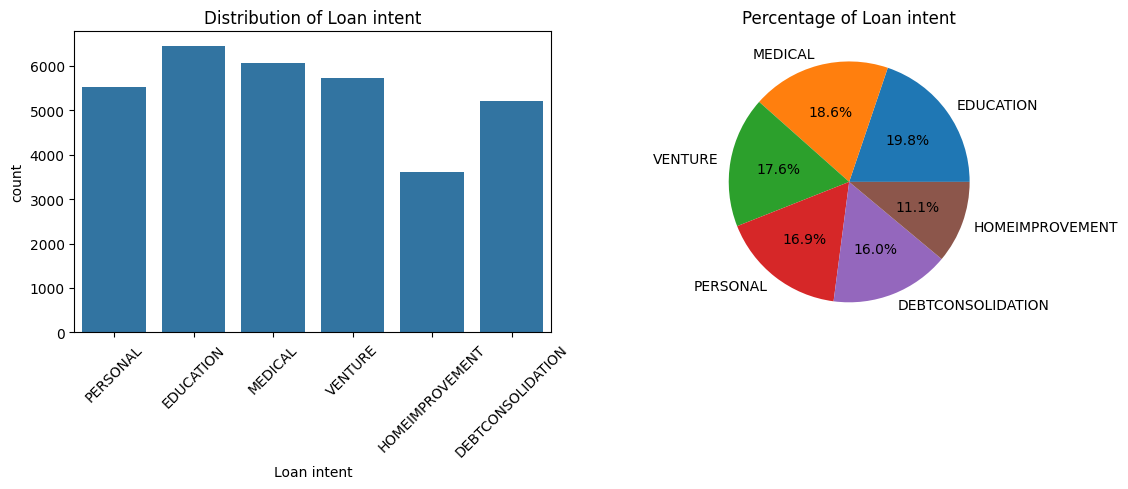

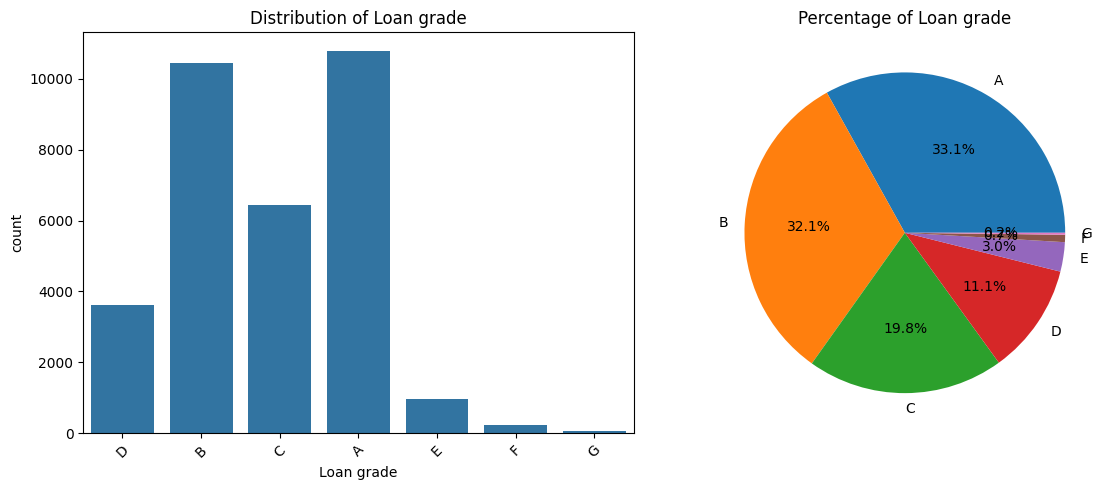

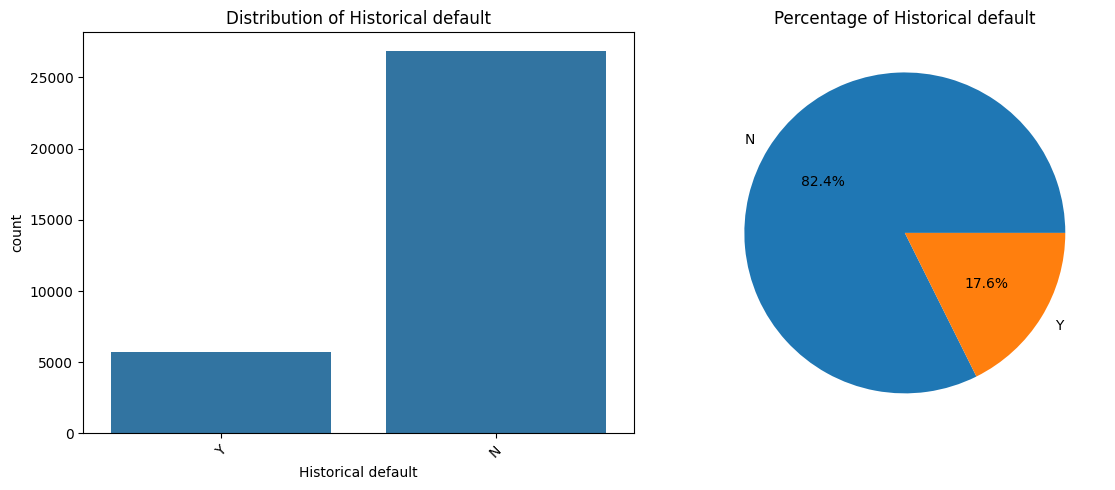

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in categorical_cols:

    print(df[col].value_counts())

    fig, ax = plt.subplots(1, 2, figsize=(12,5))


    sns.countplot(data=df, x=col, ax=ax[0])
    ax[0].set_title(f'Distribution of {col}')
    ax[0].tick_params(axis='x', rotation=45)

    df[col].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%',
        ax=ax[1]
    )
    ax[1].set_ylabel("")
    ax[1].set_title(f'Percentage of {col}')

    plt.tight_layout()


* As seen from the **Distribution of Home ownership**, Rent and Mortgage contribute the most, accounting for over 90%. It shows that most of the clients live by renting or taking or mortgage. The proportion of people actually owning a house is relatively low.
* In contrast, the distribution of **Loan intent** is relatively balanced, no single cateogry is the dominant. It could be seen that purpose of taking a loan is quite diversified, from medical reasons to education.
* **The Loan grade** distribution shows that clients with good ratings are numerous, not posing a significant financial risk.
* Eventually, the **Historical default** gives us an impression that clients are more likely to pay back their loans, bolstering the previous statement of the **Loan grade** that there was not a significant financial threat.

# **4. Correlation analysis**

<Axes: >

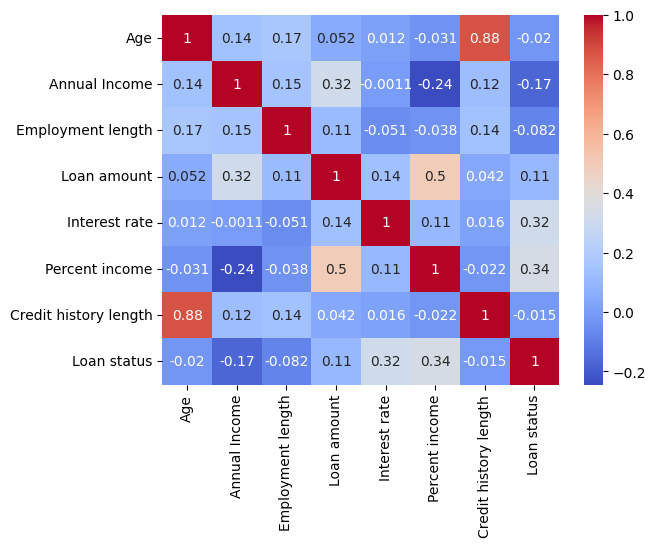

In [38]:
corr = df.corr(numeric_only=True)
sns.heatmap(data=corr, annot=True, cmap="coolwarm")

While most of the variables are not highly correlated with each other, **Age** and **Credit history length** show significantly positive correlation. The pairplot in the previous section also confirms this.

<Axes: xlabel='Age', ylabel='Credit history length'>

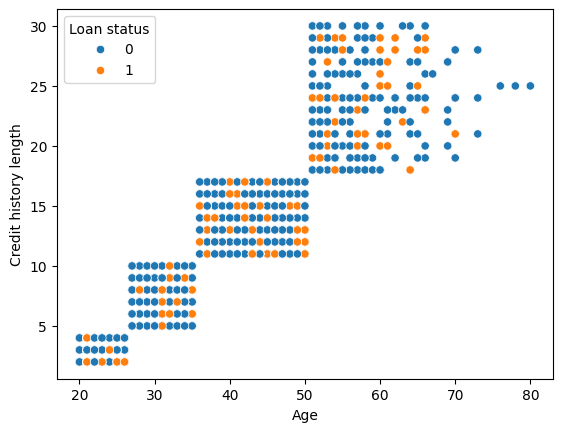

In [39]:
sns.scatterplot(data=df, x="Age", y="Credit history length", hue="Loan status")

In [40]:
corr_target = (
    df.corr(numeric_only=True)["Loan status"]
      .drop("Loan status")
      .sort_values(key=abs, ascending=False)
)

corr_target

,Loan status
Percent income,0.339625
Interest rate,0.319386
Annual Income,-0.168515
Loan amount,0.105405
Employment length,-0.082197
Age,-0.020462
Credit history length,-0.015357


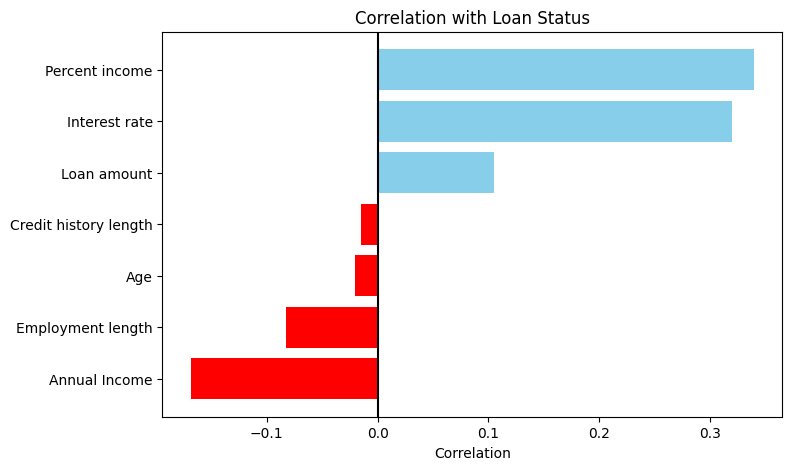

In [41]:
corr_target = corr_target.sort_values()

colors = ["red" if x < 0 else "skyblue" for x in corr_target]

plt.figure(figsize=(8,5))
plt.barh(corr_target.index, corr_target.values, color=colors)

plt.xlabel("Correlation")
plt.title("Correlation with Loan Status")
plt.axvline(0, color="black")

plt.show()

The correlation analysis indicates that the target variable is not highly correlated with any individual feature, suggesting that no single predictor alone is sufficient to explain the target variable.

In [42]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df[[
    "Annual Income",
    "Loan amount",
    "Percent income"
]]

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

          Feature       VIF
0   Annual Income  2.560327
1     Loan amount  6.008284
2  Percent income  3.579681


The Variance Inflation Factor (VIF) analysis indicates that multicollinearity is not severe among the selected numerical features. Although Loan Amount has the highest VIF (6.01), it remains below the commonly accepted threshold of 10. Annual Income (2.56) and Percent Income (3.58) exhibit relatively low VIF values. Therefore, all three variables were retained for model development.

In [43]:
X = df[["Credit history length", "Age"
]]
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

                 Feature       VIF
0  Credit history length  5.805762
1                    Age  5.805762


The VIF analysis shows that both Age and Credit History Length have moderate multicollinearity (VIF = 5.81). However, since their VIF values remain below the commonly accepted threshold of 10, the level of multicollinearity is considered acceptable, and both features were retained for further analysis